# Cahn-Hilliard loss visual check

This notebook loads the example predicted and true metadata, builds Cahn-Hilliard landscapes for two cell types first, visualizes the fields and energy densities, then computes the normalized exponential AUC loss for every cell type.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Make the notebook robust whether it is launched from the repo root or metrics/.
cwd = Path.cwd()
if (cwd / "example" / "example_result").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "example" / "example_result").exists():
    REPO_ROOT = cwd.parent
else:
    raise RuntimeError(f"Could not find repo root from {cwd}")

METRICS_DIR = REPO_ROOT / "metrics"
for path in (REPO_ROOT, METRICS_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from loss_function_plus import (  # noqa: E402
    build_continuous_landscape_from_points,
    cahn_hilliard_energy,
    cahn_hilliard_energy_density,
    shared_square_grid,
    sigmoid_bump,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
print(f"Repo root: {REPO_ROOT}")
print(f"Using device: {DEVICE}")

Repo root: /home/asalmona/Documents/Ricci/code/Tissue-Reassembly-using-GenAI-and-new-metrics
Using device: cpu


## Load and align metadata

The two CSVs share the unnamed first column as the cell ID. We align prediction and ground truth by that ID before comparing positions.

In [3]:
pred_path = REPO_ROOT / "example" / "example_result" / "metadata_pred.csv"
true_path = REPO_ROOT / "example" / "example_result" / "metadata_true.csv"

pred_df = pd.read_csv(pred_path, index_col=0)
true_df = pd.read_csv(true_path, index_col=0)

required_columns = {"cell_class", "coord_X", "coord_Y"}
for name, df in {"pred": pred_df, "true": true_df}.items():
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"{name} metadata is missing columns: {sorted(missing)}")

common_ids = true_df.index.intersection(pred_df.index)
if len(common_ids) == 0:
    raise ValueError("No shared cell IDs between true and predicted metadata.")

true_df = true_df.loc[common_ids].copy()
pred_df = pred_df.loc[common_ids].copy()

class_mismatch = (true_df["cell_class"].astype(str) != pred_df["cell_class"].astype(str)).sum()
print(f"Aligned cells: {len(common_ids)}")
print(f"Cell-class mismatches between files: {class_mismatch}")

display(true_df.head())
display(true_df["cell_class"].value_counts().rename("n_cells").to_frame())

Aligned cells: 3780
Cell-class mismatches between files: 0


,cell_class,coord_X,coord_Y
133277,Oligo,0.026848,0.116121
91841,Astro,0.052199,0.381970
55540,L6 CT,0.160931,0.067541
55257,L5 IT,0.063948,0.133388
103231,L5 ET,0.023917,0.035204


,n_cells
cell_class,
L4/5 IT,558
L2/3 IT,476
L6 CT,447
L5 IT,310
Oligo,298
Astro,296
Endo,253
L6 IT,193
L5 ET,163


## Parameters and helper functions

These values mirror the implementation in `loss_function_plus.py`. The loss compares the AUC of the Cahn-Hilliard energy curve across `RADII`.

In [49]:
# You can change these to match a training run.
RADII =np.linspace(0.001, 0.01, 16)
GRID_RESOLUTION = 256
KAPPA = 1.0
SOFT_MAX_BETA = 16.0
SUPPORT_FACTOR = 10.0
MARGIN = 0.05
SQUARE_BBOX = True
EPS = 1e-6
MIN_CELLS_PER_TYPE = 2

true_pos = torch.tensor(true_df[["coord_X", "coord_Y"]].to_numpy(), dtype=DTYPE, device=DEVICE)
pred_pos = torch.tensor(pred_df[["coord_X", "coord_Y"]].to_numpy(), dtype=DTYPE, device=DEVICE)
cell_labels = true_df["cell_class"].astype(str)


def bump_kwargs_for_radius(radius):
    # This matches CahnHilliardEnergyAUCLoss._landscape in loss_function_plus.py.
    return {"decay_rate": 4 / radius, "shift": 64 * radius}


def type_mask_for(cell_type):
    return torch.tensor((cell_labels.values == cell_type), dtype=torch.bool, device=DEVICE)


def landscape_for_points(points, grid_x, grid_y, radius):
    valid_mask = torch.ones(points.shape[0], dtype=torch.bool, device=points.device)
    return build_continuous_landscape_from_points(
        points,
        valid_mask,
        grid_x,
        grid_y,
        radius=radius,
        bump_fn=sigmoid_bump,
        bump_kwargs=bump_kwargs_for_radius(radius),
        combine="soft_max",
        soft_max_beta=SOFT_MAX_BETA,
        support_factor=SUPPORT_FACTOR,
    )


def compute_type_curves(cell_type):
    mask = type_mask_for(cell_type)
    n_cells = int(mask.sum().item())
    if n_cells < MIN_CELLS_PER_TYPE:
        return None

    true_type = true_pos[mask]
    pred_type = pred_pos[mask]
    grid_x, grid_y, dx, dy = shared_square_grid(
        true_type,
        pred_type,
        grid_resolution=GRID_RESOLUTION,
        margin=MARGIN,
        square=SQUARE_BBOX,
    )

    e_true_curve = []
    e_pred_curve = []
    phi_by_radius = {}
    energy_density_by_radius = {}

    for radius in RADII:
        phi_true = landscape_for_points(true_type, grid_x, grid_y, radius)
        phi_pred = landscape_for_points(pred_type, grid_x, grid_y, radius)

        energy_density_true = cahn_hilliard_energy_density(phi_true, dx, dy, kappa=KAPPA)
        energy_density_pred = cahn_hilliard_energy_density(phi_pred, dx, dy, kappa=KAPPA)

        e_true_curve.append(energy_density_true.sum() * dx * dy)
        e_pred_curve.append(energy_density_pred.sum() * dx * dy)
        phi_by_radius[radius] = (phi_true, phi_pred)
        energy_density_by_radius[radius] = (energy_density_true, energy_density_pred)

    radii_t = torch.tensor(RADII, dtype=DTYPE, device=DEVICE)
    e_true_t = torch.stack(e_true_curve)
    e_pred_t = torch.stack(e_pred_curve)
    auc_true = torch.trapezoid(e_true_t, radii_t)
    auc_pred = torch.trapezoid(e_pred_t, radii_t)

    relative_auc_diff = (auc_pred - auc_true).abs() / (auc_true.detach().abs() + EPS)
    exp_normalized_loss = 1.0 - torch.exp(-relative_auc_diff)

    return {
        "cell_type": cell_type,
        "n_cells": n_cells,
        "grid_x": grid_x,
        "grid_y": grid_y,
        "dx": dx,
        "dy": dy,
        "e_true_curve": e_true_t,
        "e_pred_curve": e_pred_t,
        "auc_true": auc_true,
        "auc_pred": auc_pred,
        "relative_auc_diff": relative_auc_diff,
        "loss_exp_normalized": exp_normalized_loss,
        "phi_by_radius": phi_by_radius,
        "energy_density_by_radius": energy_density_by_radius,
    }


def to_numpy(tensor):
    return tensor.detach().cpu().numpy()

## Pick two cell types and build landscapes

By default, this chooses the two most abundant cell types so the landscapes are easy to inspect. Change `selected_cell_types` manually if you want to inspect specific classes.

In [59]:
selected_cell_types = ['Peri', 'PVM']
visual_radius = 0.01

with torch.no_grad():
    visual_results = {cell_type: compute_type_curves(cell_type) for cell_type in selected_cell_types}

print(f"Selected cell types: {selected_cell_types}")
print(f"Visual radius: {visual_radius}")

Selected cell types: ['Peri', 'PVM']
Visual radius: 0.01


## Plot continuous landscapes

Each row is one cell type. Columns show the true landscape, predicted landscape, and their difference at `visual_radius`.

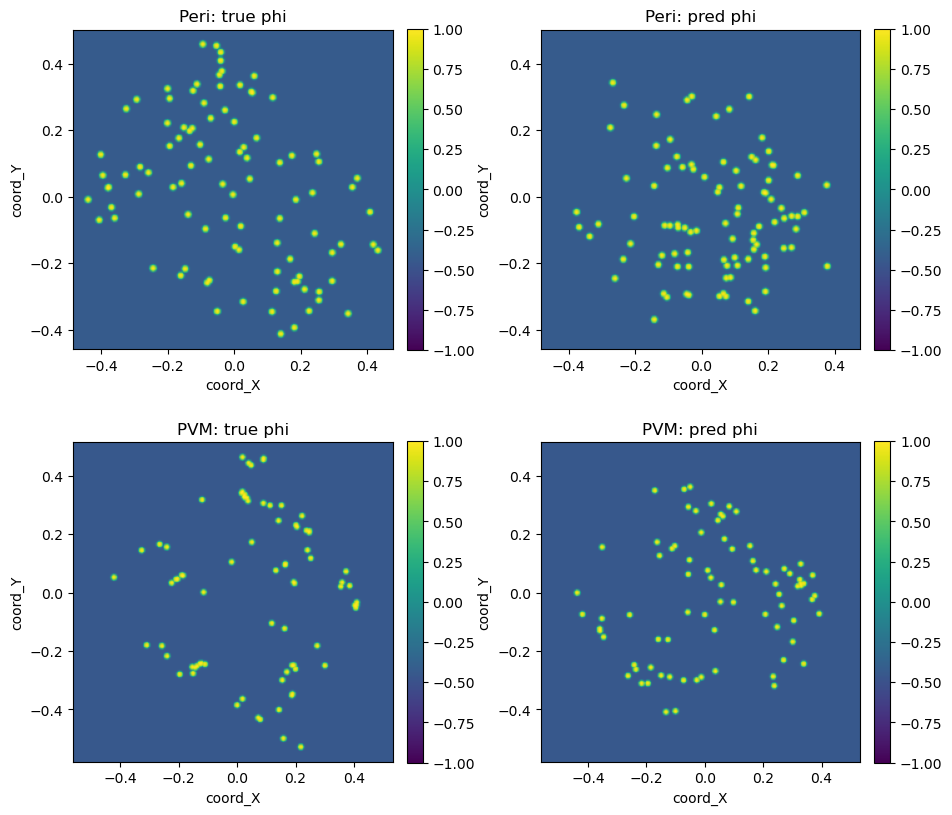

In [60]:
fig, axes = plt.subplots(len(selected_cell_types), 2, figsize=(9.5, 4.2 * len(selected_cell_types)), squeeze=False)

for row, cell_type in enumerate(selected_cell_types):
    result = visual_results[cell_type]
    phi_true, phi_pred = result["phi_by_radius"][visual_radius]
    grid_x = result["grid_x"]
    grid_y = result["grid_y"]
    extent = [grid_x.min().item(), grid_x.max().item(), grid_y.min().item(), grid_y.max().item()]

    panels = [
        (phi_true, "true phi", "viridis", -1.0, 1.0),
        (phi_pred, "pred phi", "viridis", -1.0, 1.0),
    ]
    for col, (image, title, cmap, vmin, vmax) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(to_numpy(image), origin="lower", extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"{cell_type}: {title}")
        ax.set_xlabel("coord_X")
        ax.set_ylabel("coord_Y")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
   

plt.tight_layout()

## Plot Cahn-Hilliard energy densities

These are the per-grid-cell energy densities `(phi^2 - 1)^2 + kappa * |grad phi|^2` for the same two cell types and radius.

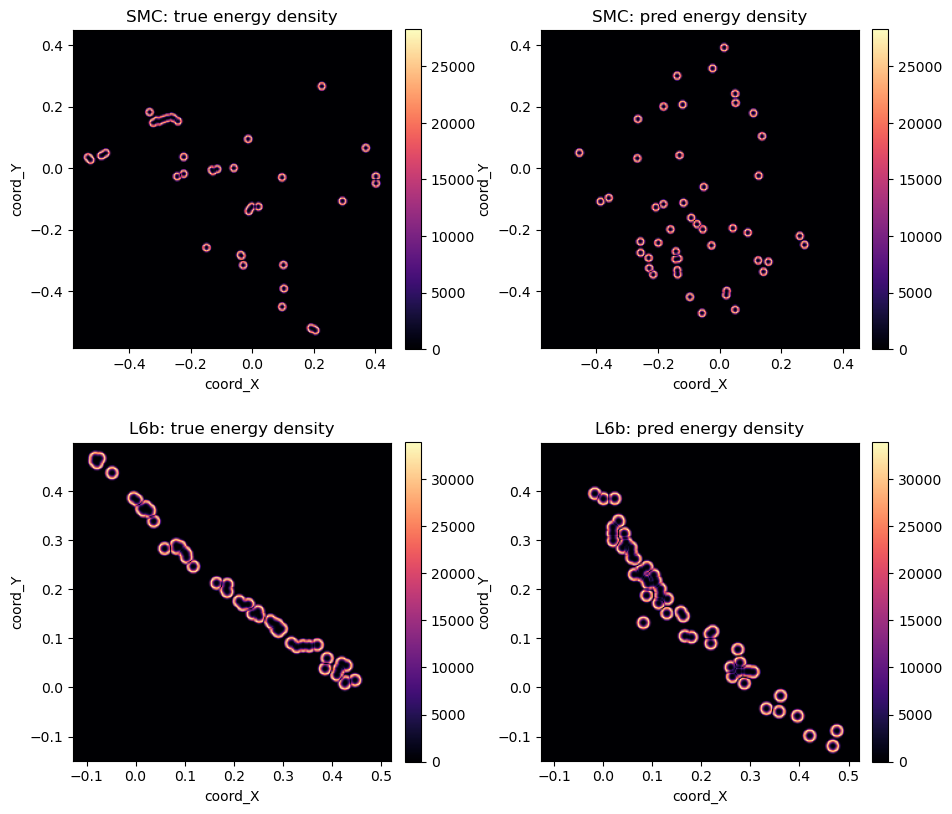

In [52]:
fig, axes = plt.subplots(len(selected_cell_types), 2, figsize=(9.5, 4.2 * len(selected_cell_types)), squeeze=False)

for row, cell_type in enumerate(selected_cell_types):
    result = visual_results[cell_type]
    e_true, e_pred = result["energy_density_by_radius"][visual_radius]
    diff = e_pred - e_true
    grid_x = result["grid_x"]
    grid_y = result["grid_y"]
    extent = [grid_x.min().item(), grid_x.max().item(), grid_y.min().item(), grid_y.max().item()]
    shared_vmax = max(float(e_true.max().item()), float(e_pred.max().item()))

    panels = [
        (e_true, "true energy density", "magma", 0.0, shared_vmax),
        (e_pred, "pred energy density", "magma", 0.0, shared_vmax),
    ]
    for col, (image, title, cmap, vmin, vmax) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(to_numpy(image), origin="lower", extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"{cell_type}: {title}")
        ax.set_xlabel("coord_X")
        ax.set_ylabel("coord_Y")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

## Plot energy curves for the two visualized cell types

The final loss compares the trapezoidal AUCs of these curves.

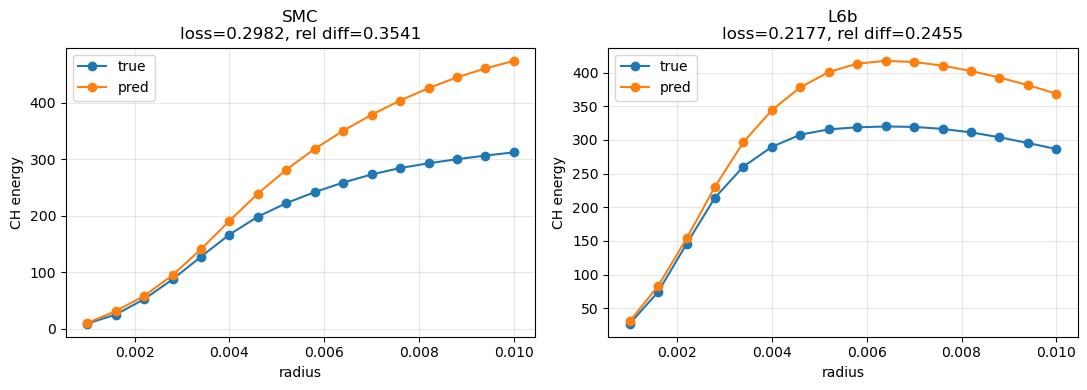

In [53]:
fig, axes = plt.subplots(1, len(selected_cell_types), figsize=(5.5 * len(selected_cell_types), 4), squeeze=False)

for col, cell_type in enumerate(selected_cell_types):
    result = visual_results[cell_type]
    ax = axes[0, col]
    ax.plot(RADII, to_numpy(result["e_true_curve"]), marker="o", label="true")
    ax.plot(RADII, to_numpy(result["e_pred_curve"]), marker="o", label="pred")
    ax.set_title(
        f"{cell_type}\n"
        f"loss={result['loss_exp_normalized'].item():.4f}, "
        f"rel diff={result['relative_auc_diff'].item():.4f}"
    )
    ax.set_xlabel("radius")
    ax.set_ylabel("CH energy")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()

## Compute the loss for every cell type

For each cell type, this computes:

`relative_auc_diff = abs(AUC_pred - AUC_true) / (abs(AUC_true) + EPS)`

`loss_exp_normalized = 1 - exp(-relative_auc_diff)`

In [54]:
all_results = []

with torch.no_grad():
    for cell_type in cell_labels.value_counts().index:
        result = compute_type_curves(cell_type)
        if result is None:
            continue
        all_results.append(
            {
                "cell_type": cell_type,
                "n_cells": result["n_cells"],
                "auc_true": result["auc_true"].item(),
                "auc_pred": result["auc_pred"].item(),
                "relative_auc_diff": result["relative_auc_diff"].item(),
                "loss_exp_normalized": result["loss_exp_normalized"].item(),
            }
        )

loss_df = pd.DataFrame(all_results).sort_values("loss_exp_normalized", ascending=False)
display(loss_df)

,cell_type,n_cells,auc_true,auc_pred,relative_auc_diff,loss_exp_normalized
17,SMC,48,1.802055,2.440216,0.354130,0.298216
16,L6b,54,2.370054,2.951977,0.245532,0.217711
13,PVM,79,2.812109,3.366718,0.197222,0.178991
14,VLMC,71,2.236173,2.540290,0.135999,0.127156
3,L5 IT,310,9.448092,8.619373,0.087713,0.083976
12,OPC,81,3.367018,3.627044,0.077227,0.074321
5,Astro,296,9.317684,8.784140,0.057261,0.055653
11,Micro,93,4.206181,3.994664,0.050287,0.049044
6,Endo,253,8.547434,8.118997,0.050125,0.048889
8,L5 ET,163,5.445458,5.695714,0.045957,0.044917


## Plot normalized exponential loss for all cell types

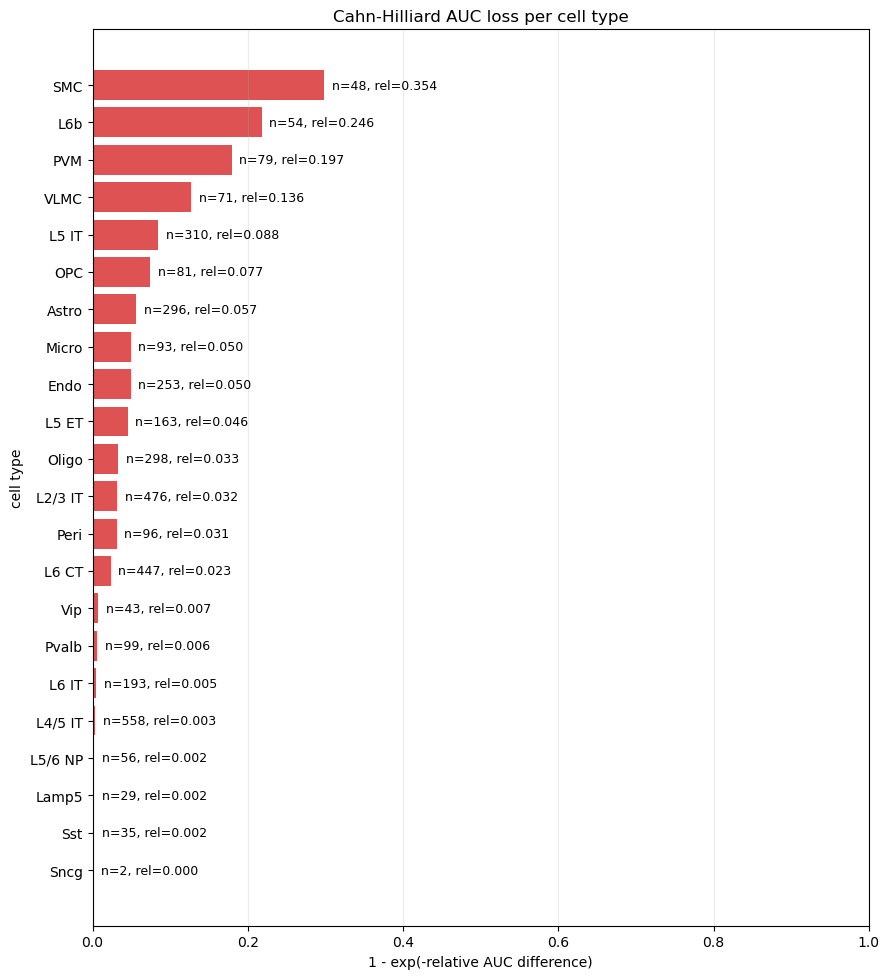

In [56]:
plot_df = loss_df.sort_values("loss_exp_normalized", ascending=True)

fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(plot_df))))
ax.barh(plot_df["cell_type"], plot_df["loss_exp_normalized"], color="tab:red", alpha=0.8)
ax.set_xlabel("1 - exp(-relative AUC difference)")
ax.set_ylabel("cell type")
ax.set_title("Cahn-Hilliard AUC loss per cell type")
ax.set_xlim(0, max(1.0, float(plot_df["loss_exp_normalized"].max()) * 1.05))
ax.grid(axis="x", alpha=0.25)

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["loss_exp_normalized"] + 0.01,
        i,
        f"n={int(row['n_cells'])}, rel={row['relative_auc_diff']:.3f}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()